In [2]:
!pip install -q langgraph

In [1]:
from IPython.display import Image, display

import random
from typing_extensions import TypedDict

from langgraph.graph import StateGraph, START, END
from langgraph.graph.state import CompiledStateGraph

**<center>Ejemplo 01:</center>**

<center>
Clasificar si correspode pagarle horas extras a un trabajador (más de 48h trabajadas en la semana)

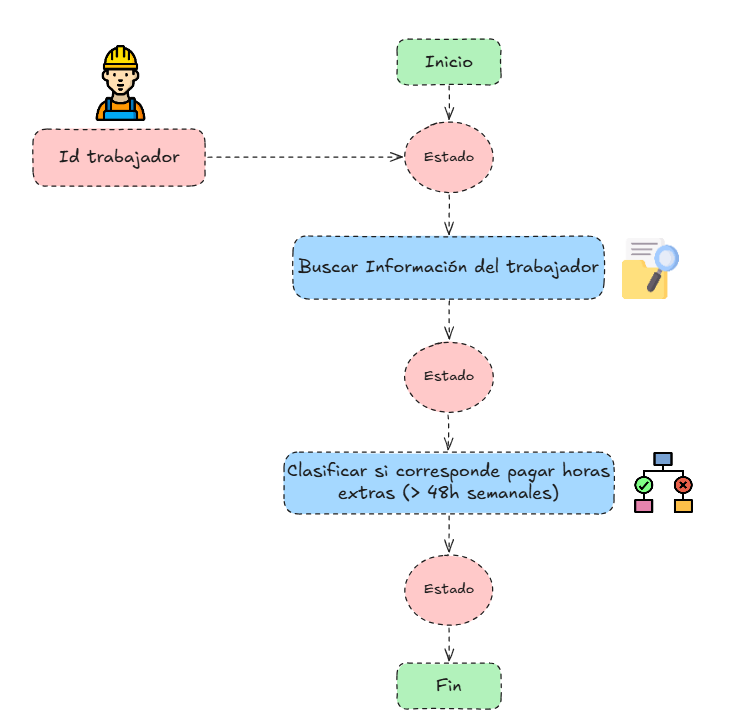</center>

In [18]:
class Estado(TypedDict):
    """
    Representa el estado del trabajador durante el flujo de procesamiento.

    Atributos:
        id_trabajador (str): Identificador único del trabajador.
        horas_trabajadas (int): Número total de horas trabajadas.
        clasificacion (str): Resultado de la clasificación respecto al pago de horas extras.
    """
    id_trabajador: str
    horas_trabajadas: int
    clasificacion: str


def buscar_informacion_trabajador(estado: Estado) -> Estado:
    """
    Simula la cantidad de horas trabajadas.

    Args:
        estado (Estado): Diccionario con la información actual del trabajador.

    Returns:
        Estado: El mismo diccionario con el campo 'horas_trabajadas' actualizado.
    """
    estado["horas_trabajadas"]: int = random.randint(40, 55)
    return estado


def determinar_horas_extras(estado: Estado) -> Estado:
    """
    Determina si corresponde el pago de horas extras según la cantidad trabajada.

    Si el trabajador supera las 48 horas, se calcula cuántas horas corresponden
    a pago adicional. En caso contrario, se indica que no aplica el pago extra.

    Args:
        estado (Estado): Diccionario con la información actual del trabajador,
            incluyendo las horas extras trabajadas.

    Returns:
        Estado: El mismo diccionario con el campo 'clasificacion' actualizado.
    """
    if estado["horas_trabajadas"] > 48:
        horas_extras: int = estado["horas_trabajadas"] - 48
        estado["clasificacion"]: str = f"Corresponde pagarle horas extras: {horas_extras}h"
    else:
        estado["clasificacion"]: str = "No corresponde pagar horas extras"

    return estado

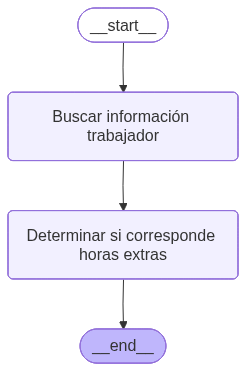

In [5]:
#Se define el estado del workflow
horas_extras_workflow: StateGraph = StateGraph(Estado)

#Se agregan los nodos
horas_extras_workflow.add_node('Buscar información trabajador', buscar_informacion_trabajador)
horas_extras_workflow.add_node('Determinar si corresponde horas extras', determinar_horas_extras)

#Se agregan los lados
horas_extras_workflow.add_edge(START, 'Buscar información trabajador')
horas_extras_workflow.add_edge('Buscar información trabajador', 'Determinar si corresponde horas extras')
horas_extras_workflow.add_edge('Determinar si corresponde horas extras', END)

#Se compila el workflow
horas_extras_workflow_compilado: CompiledStateGraph = horas_extras_workflow.compile()

display(Image(horas_extras_workflow_compilado.get_graph().draw_mermaid_png()))

In [6]:
#Consultamos por el trabajador por su id
estado: dict = Estado(id_trabajador = 'Z123')

#La respuesta será un diccionario con los estados actualizados
respuesta: dict = horas_extras_workflow_compilado.invoke(estado)

print( f"El trabajador con código {respuesta['id_trabajador']}\
  ha trabajado {respuesta['horas_trabajadas']}\
  horas en la semana, entonces {respuesta['clasificacion']}")

El trabajador con código Z123  ha trabajado 50  horas en la semana, entonces Corresponde pagarle horas extras: 2h


**<center>Ejemplo 02:</center>**

<center>Claisificar si correspode pagarle horas extras a un trabajador (más de 48h trabajadas en la semana)


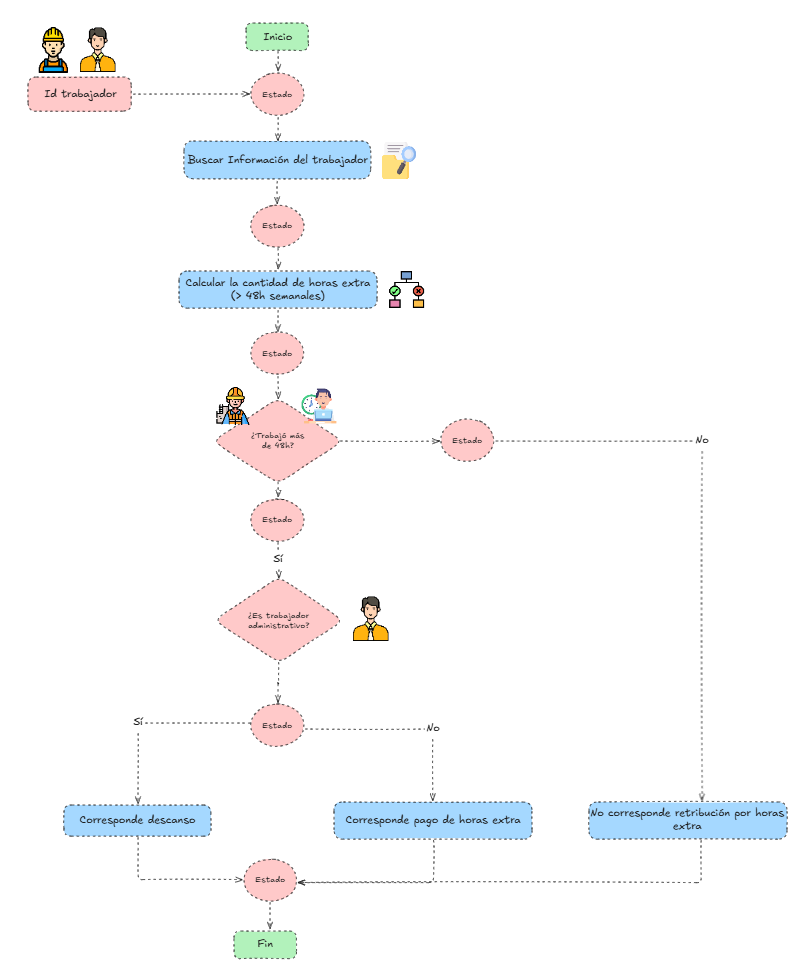</center>

In [36]:
from decimal import Decimal
from typing import TypedDict
import random


class Estado(TypedDict):
    """
    Representa el estado de un trabajador durante una semana laboral.

    Atributos:
        id_trabajador (str): Identificador único del trabajador.
        horas_trabajadas (int): Total de horas trabajadas en la semana.
        horas_extra (int): Total de horas extra acumuladas.
        clasificacion (str): Descripción del estado del trabajador.
        tipo_trabajador (str): Tipo de trabajador (por ejemplo, 'administrativo' u 'operario').
    """
    id_trabajador: str
    horas_trabajadas: int
    horas_extra: int
    clasificacion: str
    tipo_trabajador: str


def buscar_informacion_trabajador(estado: Estado) -> Estado:
    """
    Asigna información simulada del trabajador.

    Esta función genera de forma aleatoria las horas trabajadas y
    el tipo de trabajador, modificando el diccionario de estado.

    Args:
        estado (Estado): Estado inicial del trabajador.

    Returns:
        Estado: Estado actualizado con horas trabajadas y tipo de trabajador.
    """
    estado["horas_trabajadas"]: int = random.randint(40, 55)
    estado["tipo_trabajador"]: str = random.choice(["administrativo", "operario"])
    return estado


def calcular_total_horas_extra(estado: Estado) -> Estado:
    """
    Calcula el total de horas extra del trabajador.

    La cantidad de horas extra se obtiene restando 48 (límite semanal)
    del total de horas trabajadas.

    Args:
        estado (Estado): Estado actual del trabajador.

    Returns:
        Estado: Estado actualizado con el total de horas extra.
    """
    horas_extra: int = estado["horas_trabajadas"] - 48
    estado["horas_extra"]: int = horas_extra if horas_extra > 0 else 0
    return estado


def es_mas_48_horas(estado: Estado) -> str:
    """
    Verifica si el trabajador ha superado las 48 horas semanales.

    Args:
        estado (Estado): Estado del trabajador.

    Returns:
        str: 'Sí' si trabajó más de 48 horas, de lo contrario 'No'.
    """
    if estado["horas_extra"] > 0:
        return "Sí"
    else:
        return "No"


def es_trabajador_administrativo(estado: Estado) -> str:
    """
    Verifica si el trabajador pertenece al tipo 'administrativo'.

    Args:
        estado (Estado): Estado del trabajador.

    Returns:
        str: 'Sí' si es administrativo, de lo contrario 'No'.
    """
    if estado["tipo_trabajador"] == "administrativo":
        return "Sí"
    else:
        return "No"


def determinar_dias_descanso(estado: Estado) -> Estado:
    """
    Determina los días de descanso acumulados por horas extra.

    Cada 8 horas extra se considera un día de descanso.

    Args:
        estado (Estado): Estado actual del trabajador.

    Returns:
        Estado: Estado actualizado con la descripción de los días de descanso.
    """
    dias_descanso: float = round((estado["horas_extra"]) / 8, 2)
    estado["clasificacion"]: str = f"Trabajador acumula {dias_descanso} días de descanso"
    return estado


def determinar_horas_extra(estado: Estado) -> Estado:
    """
    Asigna una descripción indicando las horas extra acumuladas.

    Args:
        estado (Estado): Estado actual del trabajador.

    Returns:
        Estado: Estado actualizado con la descripción de las horas extra.
    """
    estado["clasificacion"]: str = f"Trabajador acumula en horas extra: {estado['horas_extra']}h"
    return estado


def determinar_no_extras(estado: Estado) -> Estado:
    """
    Asigna una descripción cuando el trabajador no tiene horas extra.

    Args:
        estado (Estado): Estado actual del trabajador.

    Returns:
        Estado: Estado actualizado con una descripción que indica
        que no se acumulan horas extra.
    """
    estado["clasificacion"]: str = "Trabajador no acumula horas extra"
    return estado


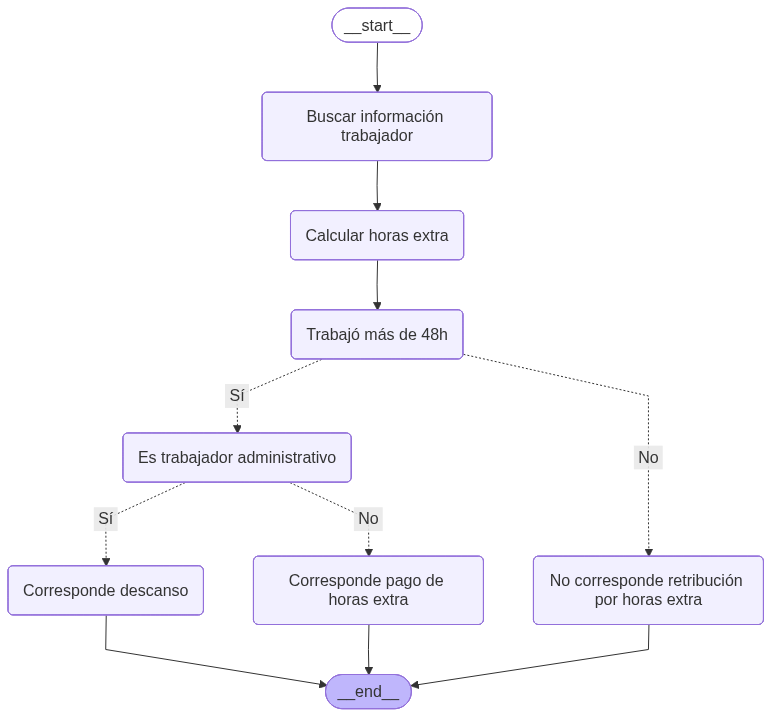

In [37]:
#Se define el estado del workflow
horas_extras_workflow_02: StateGraph = StateGraph(Estado)

#Se agregan los nodos
horas_extras_workflow_02.add_node('Buscar información trabajador', buscar_informacion_trabajador)
horas_extras_workflow_02.add_node('Calcular horas extra', calcular_total_horas_extra)
horas_extras_workflow_02.add_node('Trabajó más de 48h', lambda state: state)
horas_extras_workflow_02.add_node('Es trabajador administrativo', lambda state: state)


horas_extras_workflow_02.add_node('No corresponde retribución por horas extra', determinar_no_extras)
horas_extras_workflow_02.add_node('Corresponde descanso', determinar_dias_descanso)
horas_extras_workflow_02.add_node('Corresponde pago de horas extra', determinar_horas_extra)


#Se agregan los lados
horas_extras_workflow_02.add_edge(START, 'Buscar información trabajador')
horas_extras_workflow_02.add_edge('Buscar información trabajador', 'Calcular horas extra')
horas_extras_workflow_02.add_edge('Calcular horas extra', 'Trabajó más de 48h')
horas_extras_workflow_02.add_conditional_edges(
    'Trabajó más de 48h',
    es_mas_48_horas,
    {
        'No': 'No corresponde retribución por horas extra'
       ,'Sí': 'Es trabajador administrativo'
    }
)

horas_extras_workflow_02.add_conditional_edges(
    'Es trabajador administrativo',
    es_trabajador_administrativo,
    {
        'No': 'Corresponde pago de horas extra'
       ,'Sí': 'Corresponde descanso'
    }
)

horas_extras_workflow_02.add_edge('No corresponde retribución por horas extra', END)
horas_extras_workflow_02.add_edge('Corresponde pago de horas extra', END)
horas_extras_workflow_02.add_edge('Corresponde descanso', END)

#Se compila el workflow
horas_extras_workflow_02_compilado: CompiledStateGraph = horas_extras_workflow_02.compile()

display(Image(horas_extras_workflow_02_compilado.get_graph().draw_mermaid_png()))

In [56]:
#Consultamos por el trabajador por su id
estado: dict = Estado(id_trabajador = 'Z123')

#La respuesta será un diccionario con los estados actualizados
respuesta: dict = horas_extras_workflow_02_compilado.invoke(estado)

print( f"El trabajador con código {respuesta['id_trabajador']}\n\
Trabajador es de tipo: {respuesta['tipo_trabajador']}\n\
Horas trabajadas: {respuesta['horas_trabajadas']}\n\
Horas extra: {respuesta['horas_extra']}\n\
{respuesta['clasificacion']}")

El trabajador con código Z123
Trabajador es de tipo: operario
Horas trabajadas: 54
Horas extra: 6
Trabajador acumula en horas extra: 6h
